FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Full dataset: 14,348,689 rows
Sampled dataset: 2,000,000 rows

Target distribution:
TRANSPORTED
1    0.681
0    0.319
Name: proportion, dtype: float64

Split sizes:
  Train:      1,400,000 rows
  Validation: 300,000 rows
  Test:       300,000 rows

Training model...
Done.

── Validation Results ──────────────────────────────
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     96099
    Transported       0.82      0.58      0.68    203901

       accuracy                           0.63    300000
      macro avg       0.64      0.66      0.62    300000
   weighted avg       0.70      0.63      0.64    300000

ROC-AUC: 0.7078

── Test Results ────────────────────────────────────
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     96029
    Transported       0.82      0.57      0.68    203971

       accuracy                           0.63    300000
      macro avg       0.64  

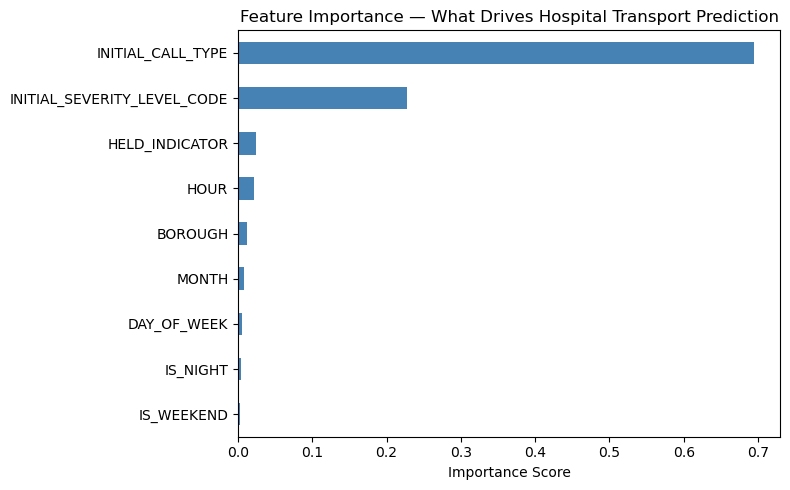

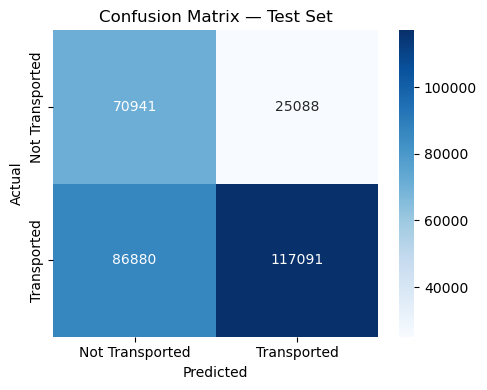


Model saved to ems_priority_model.pkl


In [2]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ─── 1. LOAD & JOIN ───────────────────────────────────────────
con = duckdb.connect()

con.execute("CREATE OR REPLACE TABLE incidents AS SELECT * FROM read_parquet('tables/incidents.parquet')")
con.execute("CREATE OR REPLACE TABLE severity  AS SELECT * FROM read_parquet('tables/severity.parquet')")
con.execute("CREATE OR REPLACE TABLE dispatch  AS SELECT * FROM read_parquet('tables/dispatch.parquet')")
con.execute("CREATE OR REPLACE TABLE location  AS SELECT * FROM read_parquet('tables/location.parquet')")

df = con.execute("""
    SELECT
        i.INCIDENT_DATETIME,
        i.HELD_INDICATOR,
        s.INITIAL_CALL_TYPE,
        s.INITIAL_SEVERITY_LEVEL_CODE,
        l.BOROUGH,
        d.FIRST_TO_HOSP_DATETIME
    FROM incidents i
    JOIN severity s ON i.CAD_INCIDENT_ID = s.CAD_INCIDENT_ID
    JOIN dispatch d ON i.CAD_INCIDENT_ID = d.CAD_INCIDENT_ID
    JOIN location l ON i.CAD_INCIDENT_ID = l.CAD_INCIDENT_ID
""").df()

print(f"Full dataset: {len(df):,} rows")

# ─── 2. SAMPLE DOWN TO 2M ROWS ────────────────────────────────
df = df.sample(n=2_000_000, random_state=42).reset_index(drop=True)
print(f"Sampled dataset: {len(df):,} rows")

# ─── 3. BUILD TARGET VARIABLE ─────────────────────────────────
df['TRANSPORTED'] = df['FIRST_TO_HOSP_DATETIME'].notna().astype(int)

print(f"\nTarget distribution:")
print(df['TRANSPORTED'].value_counts(normalize=True).round(3))

# ─── 4. FEATURE ENGINEERING ───────────────────────────────────
df['INCIDENT_DATETIME'] = pd.to_datetime(df['INCIDENT_DATETIME'])
df['HOUR']        = df['INCIDENT_DATETIME'].dt.hour
df['DAY_OF_WEEK'] = df['INCIDENT_DATETIME'].dt.dayofweek  # 0=Monday, 6=Sunday
df['MONTH']       = df['INCIDENT_DATETIME'].dt.month
df['IS_WEEKEND']  = (df['DAY_OF_WEEK'] >= 5).astype(int)
df['IS_NIGHT']    = (df['HOUR'].between(0, 6) | df['HOUR'].between(22, 23)).astype(int)

le = LabelEncoder()
cat_cols = ['INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE', 'BOROUGH', 'HELD_INDICATOR']
for col in cat_cols:
    df[col] = df[col].fillna('UNKNOWN')
    df[col] = le.fit_transform(df[col].astype(str))

features = [
    'INITIAL_CALL_TYPE',
    'INITIAL_SEVERITY_LEVEL_CODE',
    'BOROUGH',
    'HELD_INDICATOR',
    'HOUR',
    'DAY_OF_WEEK',
    'MONTH',
    'IS_WEEKEND',
    'IS_NIGHT',
]

X = df[features]
y = df['TRANSPORTED']

# ─── 5. TRAIN / VALIDATION / TEST SPLIT ───────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\nSplit sizes:")
print(f"  Train:      {len(X_train):,} rows")
print(f"  Validation: {len(X_val):,} rows")
print(f"  Test:       {len(X_test):,} rows")

# ─── 6. TRAIN MODEL ───────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")
model.fit(X_train, y_train)
print("Done.")

# ─── 7. EVALUATE ON VALIDATION SET ───────────────────────────
y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("\n── Validation Results ──────────────────────────────")
print(classification_report(y_val, y_val_pred, target_names=['Not Transported', 'Transported']))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# ─── 8. EVALUATE ON TEST SET ──────────────────────────────────
y_test_pred  = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("\n── Test Results ────────────────────────────────────")
print(classification_report(y_test, y_test_pred, target_names=['Not Transported', 'Transported']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

# ─── 9. FEATURE IMPORTANCE PLOT ───────────────────────────────
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What Drives Hospital Transport Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ─── 10. CONFUSION MATRIX ─────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ─── 11. SAVE MODEL ───────────────────────────────────────────
joblib.dump(model, 'ems_priority_model.pkl')
print("\nModel saved to ems_priority_model.pkl")